# Module 1: Asari basics

Multiple tools exist for processing mass spectra into feature tables. Asari is a recent open-source tool, described in:

Li, et al, 2023. Trackable and scalable LC-MS metabolomics data processing using asari. Nature Communications, 14(1), p.4113. (https://www.nature.com/articles/s41467-023-39889-1)

In this notebook we will use Asari from the command line interface (CLI, via the Jupyter notebook) to analyze a representative LC-MS dataset and visualize some of the data.

The notebook (and Colab) is used for teaching. In a production environment, one can run Asari as commandline and in a pipeline, with scripts etc.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/shuzhao-li-lab/asari/blob/main/notebooks/NYC2026/Module_1_Asari_basics.ipynb)

## Installing Asari

In [ ]:
# 0 - use pip to install asari if you haven't already
!pip3 install asari-metabolomics

We are using Asari version 1.18 here. 

The example dataset `MT02` can be found at https://github.com/shuzhao-li-lab/data/raw/main/data/MT02Dataset.zip .

Additionally, there exist a couple of options to run Asari via a web interface:
* Asari web-server (limited quota) [https://asari.app/]
* The spectra processing module from MetaboAnalyst [https://new.metaboanalyst.ca/MetaboAnalyst/upload/SpectraUpload.xhtml] - peak picking algorithm set to Asari

In [1]:
# 1 - load libraries and some functions

import os
import pandas as pd
import requests, zipfile, io
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from datetime import date


def print_tree(path, prefix=""):
    path = Path(path)

    entries = sorted(path.iterdir(), key=lambda p: (p.is_file(), p.name))

    for i, entry in enumerate(entries):
        connector = "└── " if i == len(entries) - 1 else "├── "
        print(prefix + connector + entry.name)

        if entry.is_dir():
            extension = "    " if i == len(entries) - 1 else "│   "
            print_tree(entry, prefix + extension)

## Example data setup

In the code block below, we'll set the path to the MT02 .mzML files, and the results folder for the Asari outputs. Asari will make the folder if it doesn't yet exist. 

If you're using this notebook on Google Colab, go ahead and use cell block 2A. 

If you're using this on your own computer, use cell block 2B with the downloaded MT02Dataset (unzipped). Make sure you updates these paths to your own computer!

In [ ]:
# 2A - on Colab only
os.makedirs("./Datasets", exist_ok=True)

datasets = [
    "https://github.com/shuzhao-li-lab/data/raw/main/data/MT02Dataset.zip",
]

for dataset in datasets:
    r = requests.get(dataset)
    if dataset.endswith(".zip"):
        z = zipfile.ZipFile(io.BytesIO(r.content))
        z.extractall("./Datasets/")
    else:
        with open("./Datasets/" + os.path.basename(dataset), "bw+") as out_fh:
            out_fh.write(r.content)

input_dir = "./Datasets/MT02Dataset/"

# check that we have 8 mzML files
print(os.listdir(input_dir))

output_dir = "./Datasets/MT02Dataset/results/"

In [2]:
# 2B - set file paths

input_dir = os.path.expanduser(
    "~/Desktop/Li_Lab/Projects/Exposome_Workshop2026/MT02Dataset/"
)

output_dir = os.path.expanduser(
    "~/Desktop/Li_Lab/Projects/Exposome_Workshop2026/MT02Dataset/results/"
)

## Running Asari

Let's use the -h flag to display the help menu and explore available options for running asari. The ! at the beginning of the command tells the notebook to run it in the command line instead of as Python code. This command will process all .mzML files in a given input_dir.

In [3]:
# 3 - look at parameters for the main asari function
! asari process -h



~~~~~~~ Hello from Asari (1.18.1) ~~~~~~~~~

usage: asari [-h] [-v] [-m MODE] [--ppm PPM] [-i INPUT] [-o OUTPUT]
             [-j PROJECT] [-p PARAMETERS] [-c MULTICORES] [-f REFERENCE]
             [--database_mode DATABASE_MODE] [--wlen WLEN]
             [--max_retention_shift MAX_RETENTION_SHIFT]
             [--num_lowess_iterations NUM_LOWESS_ITERATIONS]
             [--autoheight AUTOHEIGHT] [--min_peak_height MIN_PEAK_HEIGHT]
             [--min_prominence_threshold MIN_PROMINENCE_THRESHOLD]
             [--cal_min_peak_height CAL_MIN_PEAK_HEIGHT]
             [--min_intensity_threshold MIN_INTENSITY_THRESHOLD]
             [--peak_area PEAK_AREA] [--keep_intermediates KEEP_INTERMEDIATES]
             [--anno ANNO] [--debug_rtime_align DEBUG_RTIME_ALIGN]
             [--drop_unaligned_samples DROP_UNALIGNED_SAMPLES]
             [--kovats KOVATS] [--db DB] [--denovo DENOVO]
             [--denovo_limit DENOVO_LIMIT] [--table_for_viz TABLE_FOR_VIZ]
             [--vizualizatio

### Asari parameters

These are the main parameters you'll need to specify:

* **-i** specifies the input directory
* **-o** specififies the output directory
* **-m** indicates the ionization mode, either pos or neg

Other relevant parameters are (and note there are two dashes here):

* **--ppm** which is the m/z tolerance. The default is 5 ppm, which is typical for Orbitrap-based machines (2-5 ppm). For QTOFs, consider 5-10 ppm.
* **--min_peak_height** is the minimum intensity for a peak to be considered a real feature. The default is 100,000, which will remove most background noise and keep real signals. To explore this, plot an EIC or TIC to get a sense of noise thresholds and what the intensities of real peaks are in your data. 
* **--database_mode** either "ondisk" or "memory", if on disk, it will remove intermediate data structures (used for visualization purposes, demonstrated later)

### Processing MS data

You can ignore the warnings in the Asari output!

In [5]:
# 4 - process the example data!
!asari process -i {input_dir} -o {output_dir} -m pos --anno True



~~~~~~~ Hello from Asari (1.18.1) ~~~~~~~~~

Working on ~~ /Users/chongj/Desktop/Li_Lab/Projects/Exposome_Workshop2026/MT02Dataset/ ~~ 


[Warning] Not index found and build_index_from_scratch is False[Warning] Not index found and build_index_from_scratch is False

[Warning] Not index found and build_index_from_scratch is False[Warning] Not index found and build_index_from_scratch is False

[Warning] Not index found and build_index_from_scratch is False
[Warning] Not index found and build_index_from_scratch is False
[Warning] Not index found and build_index_from_scratch is False
[Warning] Not index found and build_index_from_scratch is False
Extracted batch14_MT_20210808_089.mzML to 3642 mass tracks (0 MS2 spectra).
Extracted batch14_MT_20210808_179.mzML to 3728 mass tracks (0 MS2 spectra).
Extracted batch14_MT_20210808_181.mzML to 3720 mass tracks (0 MS2 spectra).
Extracted batch12_MT_20210806_005.mzML to 2928 mass tracks (0 MS2 spectra).
[Warning] Not index found and build_index_fr

## Exploring Asari Outputs

Once the cell block finishes running, you should see text indicating where the final feature tables have been written to. Let's explore the results folder below.

Note, Asari appends a timestamp to the output directory name to ensure that folder names are unique. If you run the code again, you will get another folder, whose name starts with *output_dir*, with the same results.

In [ ]:
Path(output_dir).parts

('/',
 'Users',
 'chongj',
 'Desktop',
 'Li_Lab',
 'Projects',
 'Exposome_Workshop2026',
 'MT02Dataset',
 'results')

In [11]:
# 5 - list out the results output directory
parent_path = Path(output_dir).parent
dir_name = Path(output_dir).parts[-1]

result_dir = next(parent_path.glob(f"{dir_name}_*"))
print(result_dir)

print_tree(result_dir)

/Users/chongj/Desktop/Li_Lab/Projects/Exposome_Workshop2026/MT02Dataset/results_asari_project_730152653
├── export
│   ├── _mass_grid_mapping.csv
│   ├── cmap.pickle
│   ├── epd.pickle
│   ├── full_Feature_table.tsv
│   └── unique_compound__Feature_table.tsv
├── Annotated_empiricalCompounds.json
├── Feature_annotation.tsv
├── README.txt
├── preferred_Feature_table.tsv
└── project.json


IGNORE .DS_STORE! This is a hidden system file created by my macOS, not Asari.

From the tree structure above, we can see that there are two feature tables that get generated by Asari. The recommended feature table to use for downstream analysis is the **preferred_Feature_table.tsv**, which has been filtered by Asari to only high quality peaks. In contrast, all peaks are kept in **/export/full_Feature_table.tsv** if they meet signal (snr) and shape standards (part of input parameters but default values are fine for most people). That is, if a feature is only present in one sample, it will be reported, as we think this is important for applications like exposomics and personalized medicine. The filtering decisions then are left to end users.

Note the cmap.pickle file in /export - this is used in the Asari dashboard, shown in the last section of this notebook.

### Preferred feature table

Let's take a look at the preferred feature table in detail.

In [12]:
# 6 - use pandas to read the preferred feature table, note that it is .tsv, so we need to specify the delimiter character.
preferred_table = str(result_dir) + "/preferred_Feature_table.tsv"
ft_table = pd.read_csv(preferred_table, sep="\t")

ft_table.head()

,id_number,mz,rtime,rtime_left_base,rtime_right_base,parent_masstrack_id,peak_area,cSelectivity,goodness_fitting,snr,detection_counts,batch14_MT_20210808_087,batch14_MT_20210808_179,batch14_MT_20210808_089,batch14_MT_20210808_181,batch12_MT_20210806_005,batch14_MT_20210808_005,batch11_MT_20210805_005,batch13_MT_20210807_005
0,F0,83.0603,170.72,168.80,175.35,0,68325041,1.0,0.89,5,8,11999810,10883477,11774404,10342329,13572898,11857819,13777523,12448054
1,F2,84.0443,173.81,169.18,178.44,1,226350345,1.0,0.90,53,8,5537018,5494101,5592467,5333602,52570450,43934538,57645527,47681862
2,F3,84.0443,196.35,193.30,200.92,1,167057197,1.0,0.83,52,8,31328152,30341265,30316770,28138326,8059458,18888044,8880600,9818829
3,F4,84.0807,129.52,126.09,134.14,2,32803428,1.0,0.92,32,8,3605623,3256920,3562333,3194580,4956308,5738826,3854763,5571413
4,F6,84.0807,228.03,223.54,232.54,2,97428085,1.0,0.95,35,8,5588917,5832412,6514307,6054273,19908780,17520199,19715885,17983686


If you're using Google Colab, you'll need to save the **preferred_Feature_table.tsv** to your Google Drive so it can be accessed in another notebook. If this is your first time connecting Google Drive through Colab, a pop-up window will appear, asking you to authorize and sign-in to your Google account. Allow access and the feature table will be saved in your Google Drive.

In [ ]:
# 6b - only run this cell if you're on Colab!!
from google.colab import drive

drive.mount("/content/drive")

os.makedirs("/content/drive/MyDrive/NYC2026", exist_ok=True)

ft_table.to_csv(
    "/content/drive/MyDrive/NYC2026/preferred_Feature_table.tsv", sep="\t", index=False
)

#### QA/QC of feature data

The code block above shows the first 5 lines of the preferred feature table. The first 11 columns are feature descriptors, while the remaining are feature intensities per sample. Importantly:

* **peak_area** is the area under a chromatographic peak, representing total signal intensity of a feature (across all samples).
* **cSelectivity** (Chromatographic Peak Selectivity) is a numeric measure of how well a chromatograhic peak is separated from background noise and neighboring signals. A value of 1 is an ideal peak, with no noise above half of the peak height. A higher value reflects greater confidence that this is a true compound.
* **snr** (Signal-to Noise Ratio) is the ratio of peak height to noise level. Higher SNR values indicate stronger and more reliable signals.
* **goodness_fitting** is a measure of the peak shape quality, or how closely a chromatrographic peak fits a Gaussian distribution. Again, higher values indicate a better peak.

Together, these metrics are used to assess peak quality. In the next code block, let's visualize the QA/QC metrics of our example data by recreating Figure 4A from https://doi.org/10.1371/journal.pcbi.1011912. We will make four kernel density estimate (KDE) plots, 1 per metric.

For data visualization in Python, *Seaborn* (sns) is popular choice because it provides many plot types commonly used by computational biologists and data scientists. Built on top of Matplotlib, Seaborn can be used for creating pretty graphics, while Matplotlib can be used for advanced customization. This is somewhat analogous to ggplot2 within the tidyverse ecosystem, where you can use ggplot2 for rapid publication-quality visualizations, and other tidyverse packages for data manipulation.

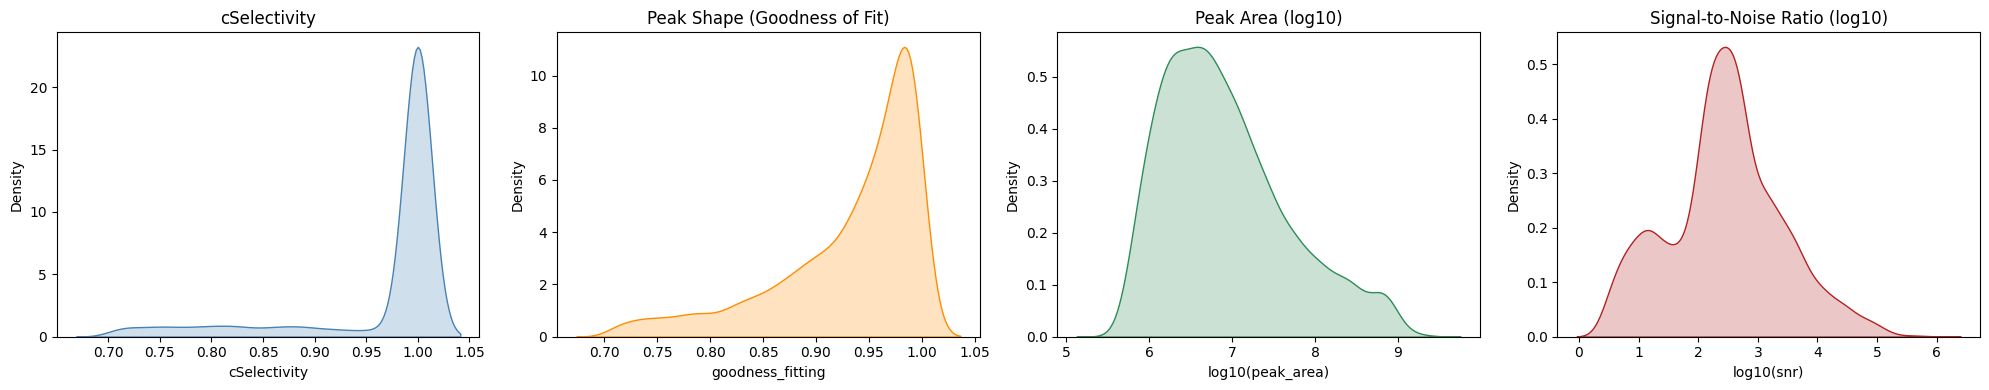

In [13]:
# 7 - QA/QC visualization

# Set up the figure, 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# 1) cSelectivity
sns.kdeplot(ft_table["cSelectivity"], fill=True, ax=axes[0], color="steelblue")
axes[0].set_title("cSelectivity")
axes[0].set_xlabel("cSelectivity")

# 2) goodness_fitting
sns.kdeplot(ft_table["goodness_fitting"], fill=True, ax=axes[1], color="darkorange")
axes[1].set_title("Peak Shape (Goodness of Fit)")
axes[1].set_xlabel("goodness_fitting")

# 3) peak_area - log10 scaled
sns.kdeplot(
    np.log10(ft_table["peak_area"].replace(0, np.nan).dropna()),
    fill=True,
    ax=axes[2],
    color="seagreen",
)
axes[2].set_title("Peak Area (log10)")
axes[2].set_xlabel("log10(peak_area)")

# 4) snr - log10 scaled
sns.kdeplot(
    np.log10(ft_table["snr"].replace(0, np.nan).dropna()),
    fill=True,
    ax=axes[3],
    color="firebrick",
)
axes[3].set_title("Signal-to-Noise Ratio (log10)")
axes[3].set_xlabel("log10(snr)")

for ax in axes:
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

### Launching the Asari Dashboard 

**LOCAL ONLY**

Use the code block below to launch the built-in interactive dashboard. A browser window should automatically open up with the dashboard showing various visualizations. The code block needs to be running to use the dashboard. 

If you accidently close the browser (as long as the block is still running) you can paste http://localhost:50002 in a browser window to open it again.

To stop the dashboard, press the stop button on the left side of the code block below.

In [15]:
# 8 - launch dashboard
!asari viz --input {result_dir}

^C
  File "/Users/chongj/miniforge3/envs/pcpfm/lib/python3.11/site-packages/scipy/interpolate/__init__.py", line 167, in <module>
    from ._interpolate import *
  File "/Users/chongj/miniforge3/envs/pcpfm/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py", line 14, in <module>
    from . import _fitpack_py
  File "/Users/chongj/miniforge3/envs/pcpfm/lib/python3.11/site-packages/scipy/interpolate/_fitpack_py.py", line 10, in <module>
    from ._bsplines import BSpline
  File "/Users/chongj/miniforge3/envs/pcpfm/lib/python3.11/site-packages/scipy/interpolate/_bsplines.py", line 9, in <module>
    from scipy.optimize import minimize_scalar
  File "/Users/chongj/miniforge3/envs/pcpfm/lib/python3.11/site-packages/scipy/optimize/__init__.py", line 438, in <module>
    from ._direct_py import direct
  File "/Users/chongj/miniforge3/envs/pcpfm/lib/python3.11/site-packages/scipy/optimize/_direct_py.py", line 9, in <module>
    from ._direct import direct as _direct  # type: ignore

## Quick statistics

In this section we will perform basic statistical analyses on our dataset. We will first generate a PCA plot using the first 2 PCs to assess whether the Qstd and NIST samples are distinct. Next, we will normalize the data and then perform feature-wise t-tests. Lastly, we will visualize one of the top differential features using a box plot to compare its intensity across Qstd and NIST samples.

In [16]:
# 9 - remember the first 11 columns are feature descriptors, let's exclude these
all_samples = ft_table.columns[11:].tolist()

ft_table_filt = ft_table.set_index("id_number")[all_samples]

# verify we subsetted to only samples and rownames are feature ids
ft_table_filt.head()

,batch14_MT_20210808_087,batch14_MT_20210808_179,batch14_MT_20210808_089,batch14_MT_20210808_181,batch12_MT_20210806_005,batch14_MT_20210808_005,batch11_MT_20210805_005,batch13_MT_20210807_005
id_number,,,,,,,,
F0,11999810,10883477,11774404,10342329,13572898,11857819,13777523,12448054
F2,5537018,5494101,5592467,5333602,52570450,43934538,57645527,47681862
F3,31328152,30341265,30316770,28138326,8059458,18888044,8880600,9818829
F4,3605623,3256920,3562333,3194580,4956308,5738826,3854763,5571413
F6,5588917,5832412,6514307,6054273,19908780,17520199,19715885,17983686


Let's check how many features (rows) and samples (columns) we have.

In [17]:
# 10 - check n rows and columns
ft_table_filt.shape

(5377, 8)

### PCA

Great, everything look's correct. Let's move onto plotting the PCA. We will be using sklearn to scale and perform PCA, which is a widely used Python library for machine learning and statistical analysis.

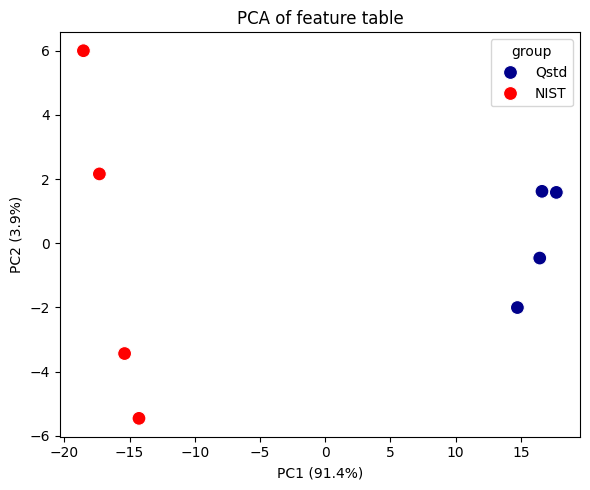

In [18]:
# 11 - run PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# list of Qstd samples
qstd_samples = [
    "batch14_MT_20210808_087",
    "batch14_MT_20210808_089",
    "batch14_MT_20210808_179",
    "batch14_MT_20210808_181",
]

# first we need to scale the data before plotting the PCA
S = StandardScaler()
P = PCA(n_components=2)

scaled = S.fit_transform(ft_table_filt)
pca_res = P.fit_transform(scaled.T)  # need to transpose

# build a dataframe for seaborn, with a group label per sample
pca_df = pd.DataFrame(pca_res, columns=["PC1", "PC2"])
pca_df["sample"] = all_samples
pca_df["group"] = ["Qstd" if s in qstd_samples else "NIST" for s in all_samples]

plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="group",
    palette={"Qstd": "darkblue", "NIST": "red"},
    s=100,
)
plt.xlabel(f"PC1 ({P.explained_variance_ratio_[0] * 100:.1f}%)")
plt.ylabel(f"PC2 ({P.explained_variance_ratio_[1] * 100:.1f}%)")
plt.title("PCA of feature table")
plt.tight_layout()
plt.show()

In the PCA plot above, the Qstd and NIST samples are completely separated along the first PC (91.4% variance explained). This suggests the samples are very different based on their metabolomics data. Since the values in our feature table are raw intensities, the distribution is likely right-skewed. Let's check in the code box below. 

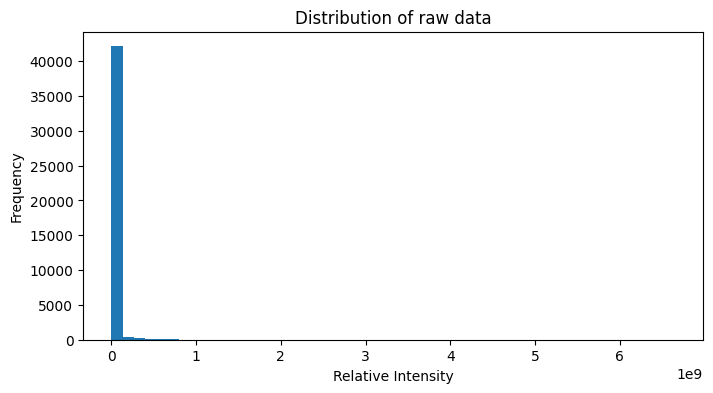

In [19]:
# 12 - plots a histogram of raw data distribution
plt.figure(figsize=(8, 4))
plt.hist(ft_table_filt.values.flatten(), bins=50)
plt.title("Distribution of raw data")
plt.xlabel("Relative Intensity")
plt.ylabel("Frequency")
plt.show()

### Log2 transformation of data

The data is extremely skewed. Let's apply log2 transformation and then plot a histogram of the transformed data to verify the data follows a Gaussian distribution. This is an important step as many statistical methods assume the data is normally distributed.

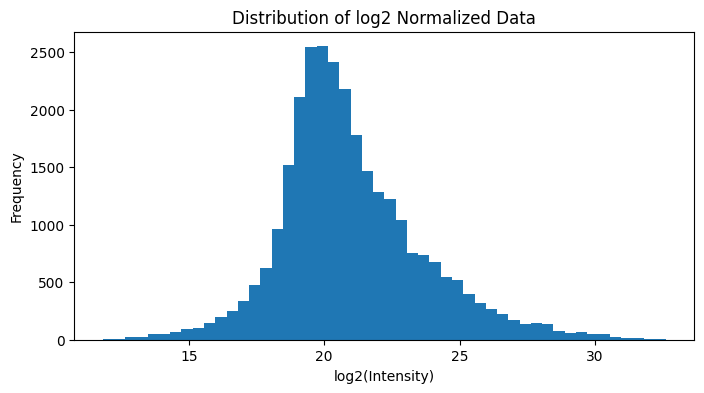

In [20]:
# 13 - log2 normalization
# Add a small constant to avoid log(0) if needed, or handle zeros appropriately
ft_table_log2 = np.log2(
    ft_table_filt.replace(0, np.nan).dropna(how="all", axis=1).dropna(how="all", axis=0)
)

# plots a histogram of log2 normalized data distribution
plt.figure(figsize=(8, 4))
plt.hist(ft_table_log2.values.flatten(), bins=50)
plt.title("Distribution of log2 Normalized Data")
plt.xlabel("log2(Intensity)")
plt.ylabel("Frequency")
plt.show()

One additional data processing step is to remove features with zero variance in our data. These are uninformative features, and removing them will help speed up our downstream analyses by reducing the size of the dataset.

In [21]:
# 14 - remove features with 0 variance

qstd_cols = [s for s in all_samples if s in qstd_samples]
nist_cols = [s for s in all_samples if s not in qstd_samples]

ft_table_log2 = ft_table_log2.loc[
    (ft_table_log2[qstd_cols].var(axis=1) > 0)
    & (ft_table_log2[nist_cols].var(axis=1) > 0)
]

ft_table_log2.shape


(2845, 8)

### Running t-tests

We went from 5377 to 2845 features! Let's run the t-tests on the filtered data now.

In [ ]:
# 15 - run t-tests
from scipy.stats import ttest_ind


def ttest_feature(row):
    _, p = ttest_ind(row[qstd_cols], row[nist_cols], equal_var=False, nan_policy="omit")
    return p


# use the ttest function on our data
pvalues_featurelist = ft_table_log2.apply(ttest_feature, axis=1)

# sort p-values
pvalues_featurelist = pvalues_featurelist.sort_values()

# convert the t-test list to a pd dataframe and export
pvalues_df = pvalues_featurelist.to_frame(name="pvalue").reset_index()
pvalues_df.columns = ["feature", "pvalue"]
pvalues_df.head()

,feature,pvalue
0,F2947,7.452922e-12
1,F6076,4.318696e-11
2,F1216,1.257479e-09
3,F3250,2.999350e-09
4,F2746,3.756163e-09


Lastly, let's generate box plots of the top 5 differential features. First we will save t-test outputs and create a metadata file of sample names and groups for plotting. Don't forget to update the file paths here!

In [ ]:
# 16 - save ttest outputs and make/save metadata

ttest_output_dir = os.path.expanduser(output_dir + "ttest_results/")
os.makedirs(ttest_output_dir, exist_ok=True)

tsv_path = os.path.join(
    ttest_output_dir,
    f"{date.today().strftime('%Y-%m-%d')}_ttest_results.tsv",
)

pvalues_df.to_csv(tsv_path, sep="\t", index=False)
print(f"Saved TSV  ({len(pvalues_df)} rows)    → {tsv_path}")

# make a metadata df
sample_df = pd.DataFrame(
    {
        "sample": all_samples,
        "group": ["Qstd" if s in qstd_samples else "NIST" for s in all_samples],
    }
)

sample_df.head()

tsv_path_metadata = os.path.join(
    ttest_output_dir,
    f"{date.today().strftime('%Y-%m-%d')}_metadata.tsv",
)

sample_df.to_csv(tsv_path_metadata, sep="\t", index=False)
print(f"Saved TSV  ({len(sample_df)} rows)    → {tsv_path_metadata}")

Saved TSV  (2845 rows)    → /Users/chongj/Desktop/Li_Lab/Projects/Exposome_Workshop2026/MT02Dataset/results/ttest_results/2026-07-30_ttest_results.tsv
Saved TSV  (8 rows)    → /Users/chongj/Desktop/Li_Lab/Projects/Exposome_Workshop2026/MT02Dataset/results/ttest_results/2026-07-30_metadata.tsv


In [24]:
# 17 - transform and save the feature intensity data
plot_data = ft_table_log2.T.reset_index(names="sample")
plot_data.head()

tsv_path_plot_data = os.path.join(
    ttest_output_dir,
    f"{date.today().strftime('%Y-%m-%d')}_plot_data.tsv",
)

plot_data.to_csv(tsv_path_plot_data, sep="\t", index=False)
print(f"Saved TSV  ({len(plot_data)} rows)    → {tsv_path_plot_data}")

Saved TSV  (8 rows)    → /Users/chongj/Desktop/Li_Lab/Projects/Exposome_Workshop2026/MT02Dataset/results/ttest_results/2026-07-30_plot_data.tsv


### Box plots of differential features

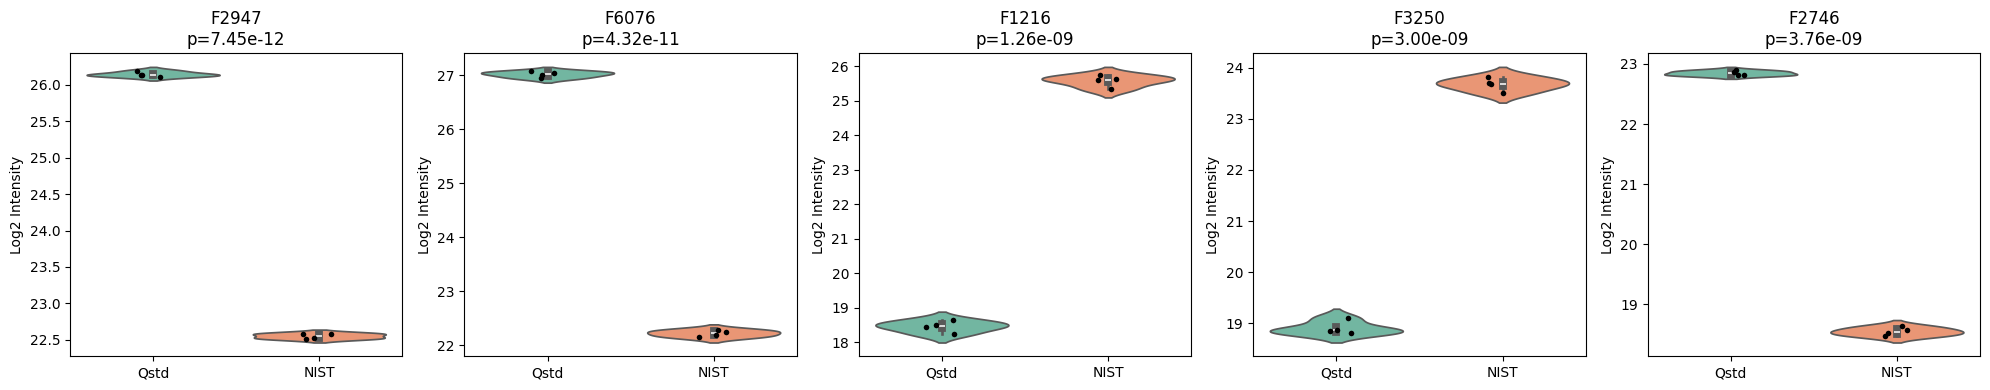

In [25]:
# 18 - merge metadata and plot data into one dataframe
# Make boxplots
boxplot_data = pd.merge(
    plot_data,
    sample_df,
    on="sample",
    how="left",
)

# Top 5 features
top5 = pvalues_df.head(5)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, (_, row) in zip(axes, top5.iterrows()):
    this_feat = row["feature"]
    this_pval = row["pvalue"]

    sns.violinplot(
        data=boxplot_data,
        x="group",
        y=this_feat,
        hue="group",
        palette="Set2",
        ax=ax,
        legend=False,
    )

    sns.stripplot(
        data=boxplot_data,
        x="group",
        y=this_feat,
        color="black",
        size=4,
        ax=ax,
    )

    ax.set_title(f"{this_feat}\np={this_pval:.2e}")
    ax.set_xlabel("")
    ax.set_ylabel("Log2 Intensity")

plt.tight_layout()
plt.show()

# Summary

In this notebook, we demonstrated how to process .mzML files through Asari to generate a feature table and examined key QA/QC metrics of feature quality. We then went through a short but typical two-group comparison analysis to identify features that differ between experimental groups.
